# Глубокое обучение 


## Тема 6. Энергетические модели ⚡️ 

__Энергетические модели__ (Energy-Based Models, EBM) ориентированы на задачу оценки плотности вероятностного распределения. Имея набор данных с большим количеством элементов, мы хотим оценить распределение вероятностей по всему пространству данных. Например, если мы моделируем изображения из набора `CIFAR10`, нашей целью будет получить распределение вероятностей по всем возможным изображениям размером $32\times32\times3$, которые с высокой вероятностью выглядят реалистично и относятся к одному из 10 классов набора `CIFAR`. Простые методы, такие как интерполяция между изображениями, не работают, поскольку изображения имеют чрезвычайно высокую размерность (особенно для больших HD-изображений). 

Как спрогнозировать распределение вероятностей $p(\mathbf{x})$ по такому количеству измерений с помощью простой нейронной сети? Проблема в том, что мы не можем просто предсказать значение от 0 до 1, поскольку распределение вероятностей по данным должно удовлетворять двум свойствам:

1. Распределение вероятностей должно присваивать любому возможному значению $\mathbf{x}$ неотрицательное значение: $p(\mathbf{x}) \geq 0$.
2. Плотность вероятности должна суммироваться/интегрироваться до 1 по **всем** возможным входным данным: $\int_{\mathbf{x}} p(\mathbf{x}) d\mathbf{x} = 1$.

Существует множество подходов для этого, и один из них — энергетические модели. Основная идея энергетических моделей заключается в том, что любую функцию, предсказывающую значения больше нуля, можно преобразовать в распределение вероятностей, разделив её на интеграл (сумму) по всему пространству. Пусть выходом нейронной сети является один нейрон, как в нейронной сети для задачи регрессии. Эту сеть можно обозначить как $E_{\theta}(\mathbf{x})$, где $\theta$ — параметры сети, а $\mathbf{x}$ — входные данные (например, изображение). Выход $E_{\theta}$ — скалярное значение в диапазоне от $-\infty$ до $\infty$. Теперь мы можем использовать базовую теорию вероятностей для *нормализации* оценок всех возможных входных данных:

$$
q_{\theta}(\mathbf{x}) = \frac{\exp\left(-E_{\theta}(\mathbf{x})\right)}{Z_{\theta}} \text{, где}\hspace{5mm}
Z_{\theta} = \begin{cases}
\int_{\mathbf{x}}\exp\left(-E_{\theta}(\mathbf{x})\right) d\mathbf{x}, & \text{если }\mathbf{x}\text{ непрерывная}\\
\sum_{\mathbf{x}}\exp\left(-E_{\theta}(\mathbf{x})\right), & \text{если }\mathbf{x}\text{ дискретная}
\end{cases}
$$

Функция $\exp$ гарантирует, что мы присваиваем любому возможному входному значению вероятность больше нуля. Мы используем знак «минус» перед $E$, поскольку $E_{\theta}$ называется __функцией энергии__: точки данных с высокой вероятностью имеют низкую энергию, в то время как точки данных с низкой вероятностью — высокую. $Z_{\theta}$ — это наш нормировочный член, который гарантирует, что плотность интегрирования/суммы равна 1. Это можно показать, проинтегрировав по $q_{\theta}(\mathbf{x})$:

$$
\int_{\mathbf{x}}q_{\theta}(\mathbf{x})d\mathbf{x} =
\int_{\mathbf{x}}\frac{\exp\left(-E_{\theta}(\mathbf{x})\right)}{\int_{\mathbf{\tilde{x}}}\exp\left(-E_{\theta}(\mathbf{\tilde{x}})\right) d\mathbf{\tilde{x}}}d\mathbf{x} =
\frac{\int_{\mathbf{x}}\exp\left(-E_{\theta}(\mathbf{x})\right)d\mathbf{x}}{\int_{\mathbf{\tilde{x}}}\exp\left(-E_{\theta}(\mathbf{\tilde{x}})\right) d\mathbf{\tilde{x}}} = 1
$$

Обратите внимание, что мы называем это распределение вероятностей $q_{\theta}(\mathbf{x})$, поскольку это распределение, полученное моделью и обученное быть максимально близким к *истинному*, неизвестному распределению $p(\mathbf{x})$.

Главное преимущество этой формулировки распределения вероятностей — её большая гибкость, поскольку мы можем выбирать $E_{\theta}$ любым удобным для нас способом, без каких-либо ограничений. Функция разбиения $Z_{\theta}$ не зависит от значения $\mathbf{x}$, но является функцией параметров $\theta$. Поскольку в моделях EBM обычно не делается никаких марковских предположений (в отличие от направленных графических моделей), вычисление этого интеграла обычно является трудной задачей, так как аналитически рассчитать $Z_{\theta}$ для многомерных входных данных и/или более крупных нейронных сетей невозможно. Хотя мы не можем определить точную вероятность точки, существуют методы обучения энергетических моделей.

Энергетические модели заимствуют ключевую идею моделирования физических систем, а именно, что вероятность какого-либо события может быть выражена с использованием функции распределения Больцмана, которая нормализует вещественнозначную энергетическую функцию между 0 и 1. Это распределение было первоначально сформулировано в 1868 году Людвигом Больцманом, который использовал его для описания газов, находящихся в тепловом равновесии.

В статистической механике и математике распределение Больцмана (также называемое распределением Гиббса) — это распределение вероятностей или вероятностная мера, которая дает вероятность того, что система будет находиться в определенном состоянии как функцию энергии этого состояния и температуры системы. 

### Оценка максимального правдоподобия

__Оценка максимального правдоподобия__ (maximum likelihood estimation, MLE) является стандартом де-факто для изучения вероятностных моделей на основе независимых одинаково распределенных (iid) данных. 

Пусть $p_{\theta}\left(\mathbf{x}\right)$ – вероятностная модель, параметризованная $\theta$, а $p_{D}\left(\mathbf{x}\right)$ — распределение данных в наборе $D$. Мы можем подогнать модель  $p_{\theta}\left(\mathbf{x}\right)$ к распределению  $p_{D}\left(\mathbf{x}\right)$, максимизируя __функцию ожидаемого логарифмического правдоподобия__ на распределении данных набора $D$, определяемую как функция от $\theta$ в виде

$$l\left(\theta\right)=\mathbb{E}_{\mathbf{x}\sim p_{D}\left(\mathbf{x}\right)}\left[\log p_{\theta}\left(\mathbf{x}\right)\right]$$

Здесь математическое ожидание $\mathbb{E}_{\mathbf{x}\sim p_{D}\left(\mathbf{x}\right)}$ можно легко оценить с помощью выборки из набора данных $D$. 

Максимизация правдоподобия $l\left(\theta\right)$ эквивалентна минимизации __KL дивергенции__ (дивергенции Кульбака-Лейблера) между распределениями $p_{D}\left(\mathbf{x}\right)$ и $p_{\theta}\left(\mathbf{x}\right)$, поскольку

$$l\left(\theta\right)=-D_{KL}\left(p_{D}\left(\mathbf{x}\right)\parallel p_{\theta}\left(\mathbf{x}\right)\right)+c,$$

где константа $c=\mathbb{E}_{\mathbf{x}\sim p_{D}\left(\mathbf{x}\right)}\left[\log p_{D}\left(\mathbf{x}\right)\right]$ не зависит от параметров $\theta$. Здесь

$$
D_{KL}\left(p_{D}\left(\mathbf{x}\right)\parallel p_{\theta}\left(\mathbf{x}\right)\right)
=\int _{X}\,p_{D}\left(\mathbf{x}\right)\log {\frac {p_{D}\left(\mathbf{x}\right)}{p_{\theta}\left(\mathbf{x}\right)}}\,{\rm {d}}x.
$$

Обычно мы не можем явно вычислить правдоподобие $l\left(\theta\right)$ для EBM, потому что нормализующая константа $Z_{\theta}$ в знаменателе часто не может быть вычислена. Тем не менее, мы можем оценить градиент логарифмического правдоподобия с помощью подходов MCMC (Markov Chain Monte Carlo, методы Монте-Карло с марковскими цепями), производя максимизацию правдоподобия с помощью стохастического градиентного подъема. В частности, градиент логарифмического правдоподобия EBM разлагается на сумму двух слагаемых:

$$\nabla_{\theta}\log p_{\theta}\left(\mathbf{x}\right)=-\nabla_{\theta}\mathcal{E}_{\theta}\left(\mathbf{x}\right)-\nabla_{\theta}\log Z_{\theta}.$$

Первый член суммы $-\nabla_{\theta}\mathcal{E}_{\theta}\left(\mathbf{x}\right)$ легко вычислить с помощью автоматического дифференцирования. Основная трудность состоит в аппроксимации второго члена суммы $\nabla_{\theta}\log Z_{\theta}$, который сложно вычислить точно. Этот градиентный член можно переписать как следующее математическое ожидание:

$$\nabla_{\theta}\log Z_{\theta}=\frac{1}{Z_{\theta}}\nabla_{\theta}Z_{\theta}=\frac{1}{Z_{\theta}}\nabla_{\theta}\intop\exp\left(-\mathcal{E}_{\theta}\left(\mathbf{x}\right)\right)d\mathbf{x}=\frac{1}{Z_{\theta}}\intop\nabla_{\theta}\exp\left(-\mathcal{E}_{\theta}\left(\mathbf{x}\right)\right)d\mathbf{x}=$$

$$=\frac{1}{Z_{\theta}}\intop\exp\left(-\mathcal{E}_{\theta}\left(\mathbf{x}\right)\right)\left(-\nabla_{\theta}\mathcal{E}_{\theta}\left(\mathbf{x}\right)\right)d\mathbf{x}=\intop\frac{1}{Z_{\theta}}\exp\left(-\mathcal{E}_{\theta}\left(\mathbf{x}\right)\right)\left(-\nabla_{\theta}\mathcal{E}_{\theta}\left(\mathbf{x}\right)\right)d\mathbf{x}=$$

$$=\intop p_{\theta}\left(\mathbf{x}\right)\left(-\nabla_{\theta}\mathcal{E}_{\theta}\left(\mathbf{x}\right)\right)d\mathbf{x}=\mathbb{E}_{\mathbf{x}\sim p_{\theta}\left(\mathbf{x}\right)}\left[-\nabla_{\theta}\mathcal{E}_{\theta}\left(\mathbf{x}\right)\right]$$

Таким образом, мы можем получить несмещенную оценку $\nabla_{\theta}\log Z_{\theta}$ градиента логарифмического правдоподобия  __методом Монте-Карло__ следующим образом:

$$\nabla_{\theta}\log Z_{\theta}\approx-\frac{1}{S}\sum_{s=1}^{S}\nabla_{\theta}\mathcal{E}_{\theta}\left(\mathbf{\tilde{x}}_{s}\right),$$

где $\mathbf{\tilde{x}}_{s}\sim p_{\theta}\left(\mathbf{x}\right)$, то есть $\mathbf{\tilde{x}}_{s}$ – это случайная выборка из распределения $p_{\theta}\left(\mathbf{x}\right)$ для значения $\mathbf{x}$, заданного моделью EBM. Следовательно, если мы умеем делать случайные выборки из распределения $p_{\theta}\left(\mathbf{x}\right)$ модели EBM, у нас есть несмещенная оценка градиента логарифмического правдоподобия по методу Монте-Карло, что позволяет нам оптимизировать параметры модели при помощи стохастического градиентного подъема. 

### Генерация случайных величин

#### Преобразования

Если мы можем сгенерировать случайную величину $Z$, имеющую некоторое распределение, и $V=g\left(Z\right)$, то мы можем сгенерировать случайную величину $V$. Поэтому один из подходов — это представление случайной величины как преобразования другой случайной величины — в идеале, как преобразования легко генерируемой случайной величины. 

Например, предположим, что мы можем генерировать случайные числа из стандартного распределения Гаусса $Z\sim\mathcal{N}\left(0,1\right)$. Тогда мы можем получать выборку из распределения $\mathcal{N}\left(\mu,\sigma^{2}\right)$ как величину $\sigma Z+\mu$. Можно сгенерировать случайную величину $\chi^{2}$ с одной степенью свободы как $Z^{2}$. Можно сгенерировать случайную величину $\chi^{2}$ с $d$ степенями свободы, суммируя $d$ независимых копий $Z^{2}$. 

В частности, если мы можем генерировать случайные числа, равномерно распределенные между 0 и 1, то  мы можем использовать это для генерации всех случайных величин, которые являются преобразованиями равномерного распределения. 

#### Метод квантилей

Предположим, что мы знаем квантильную функцию $Q_{Z}$ для случайной величины $Z$, так что $Q_{Z}(0.5)$ является медианой $Z$, $Q_{Z}(0.9)$ является 90-м процентилем, а в общем случае значение $Q_{Z}(p)$ больше или равно $Z$ (точнее случайная величина $Z$ не превышает $Q_{Z}(p)$) с вероятностью $p$. Квантильная функция $Q_{Z}$ рассматривается в паре с кумулятивной функцией распределения (cdf) $F_{Z}$, так как

$$Q_{Z}\left(F_{Z}\left(x\right)\right)=x,\,F_{Z}\left(Q_{Z}\left(p\right)\right)=p$$

В методе квантилей (или методе преобразования обратным распределением) мы генерируем случайное число $U$ с равномерным распределением на $\left[0,1\right]$ и передаем его в качестве аргумента функции $Q_{Z}$. Теперь $Q_{Z}\left(U\right)$ имеет функцию распределения $F_{Z}$:

$$\Pr\left[Q_{Z}\left(U\right)\leqslant x\right]=\Pr\left[F_{Z}\left(Q_{Z}\left(U\right)\right)\leqslant F_{Z}\left(x\right)\right]=\Pr\left[U\leqslant F_{Z}\left(x\right)\right]=F_{Z}\left(x\right),$$

где в последнем равенстве используется тот факт, что $U$ равномерна на $[0,1]$, а в первом равенстве используется тот факт, что $F_{Z}$ — неубывающая функция, поэтому $b\leqslant a$ истинно тогда и только тогда, когда $F_{Z}\left(b\right)\leqslant F_{Z}\left(а\right)$.

__Пример__. CDF экспоненциального распределения с параметром $\lambda$ равна $1-e^{-\lambda x}$. Таким образом, функция квантиля $Q\left(p\right)$ равна $-\frac{1}{\lambda}\log\left(1-p\right)$. Обратите внимание, что эта величина положительна, потому что $1-p<1$ и, следовательно, $\log\left(1-p\right)<0$. Следовательно, если $U\sim\mathrm{Unif}\left(0,1\right)$, то $-\frac{1}{\lambda}\log\left(1-U\right)\sim\mathrm{Exp}\left(\lambda\right)$.

__Пример__. Распределение Парето или степенной закон представляет собой двухпараметрическое семество $f\left(x;\alpha,x_{0}\right)=\frac{\alpha-1}{x_{0}}\left(\frac{x}{x_{0}}\right)^{-\alpha}$, если $x\geqslant x_{0}$ и с плотностью, равной нулю, в противном случае. Интегрирование показывает, что кумулятивная функция распределения равна $F\left(x;\alpha,x_{0}\right)=1-\left(\frac{x}{x_{0}}\right)^{-\alpha+1}$. Поэтому квантильная функция равна $Q\left(p;\alpha,x_{0}\right)=x_{0}\left(1-p\right)^{-\frac{1}{\alpha-1}}$.

__Пример__. Стандартное гауссово распределение $\mathcal{N}\left(0,1\right)$ не имеет замкнутой формы для своей квантильной функции, но есть быстрые и точные способы ее численного вычисления, поэтому можно использовать квантильный подход. На практике есть и другие методы преобразования, которые еще быстрее, но основаны на специальных приемах. 

Поскольку $Q_{Z}\left(U\right)$ имеет ту же функцию распределения, что и $X$, мы можем использовать метод квантилей, если мы можем вычислить $Q_{Z}$. Так как функция $Q_{Z}$ существует всегда, в принципе это решает проблему. Однако на практике нам нужно рассчитать значение $Q_{Z}$, прежде чем мы сможем его использовать, и функция $Q_{Z}$ может не иметь замкнутой формы, а численные приближения могут быть трудновыполнимыми.

#### Метод отклонения (Rejection Method)

Другим общим подходом, при котором квантильная функция не требуется, является метод отклонения. Предположим, что мы хотим сгенерировать случайную величину $Z$ с функцией плотности вероятности $f_{Z}$ и у нас есть метод для генерации случайной величины $R$ с функцией плотности распределения $\rho$, называемого предлагаемым распределением (proposal distribution). Также предположим, что $f_{Z}\left(x\right)\leqslant\rho(x)\,M$ для некоторой константы $M>1$. Например, если $f_{Z}$ отлична от нуля на ограниченном интервале $\left[a,b\right]$, то мы могли бы взять $\rho$ как равномерное распределение на $\left[a,b\right]$, и $M$ как максимальное значение плотности $f_{Z}$. Алгоритм метода отклонения тогда выглядит следующим образом.

1. Сгенерируйте предлагаемое значение случайной величины $R$ с плотностью $\rho$. 

2. Сгенерируйте случайную величину $U$ с равномерным распределением и независимую от $R$. 

3. Проверяем, выполняется ли условие $M\,U\,\rho\left(R\right)<f_{Z}\left(R\right)$.

    * Если да, то «принимаем предложение», возвращая $R$ и останавливаясь.

    * Если нет, то «отклоняем предложение», отбрасываем $R$ и $U$ и возвращаемся к шагу 1.

Если $\rho$ – плотность равномерного распределения, то эта проверка сводится к проверке условия $M\,U<f_{Z}\left(R\right)$, где $M$ – максимальная плотность $Z$.

Один из способов понять метод отклонения заключается в следующем. Представьте график кривой $f_{Z}\left(x\right)$. Общая площадь под этой кривой равна $1$, так как $\int f_{Z}\left(x\right)dx=1$. Площадь между любыми двумя точками $a$ и $b$ на горизонтальной оси равна $\int_{a}^{b}f_{Z}\left(x\right)dx=F_{Z}\left(b\right)-F_{Z}\left(a\right)$. Отсюда следует, что если бы мы могли равномерно выбирать точки из области между кривой и горизонтальной осью координат, то их координаты x имели бы именно ту функцию распределения, которую мы ищем. Если функция плотности $\rho$ является плотностью равномерного распределения, то мы рисуем прямоугольник, который охватывает кривую $f_{Z}$, равномерно отбирая точки из прямоугольника ($R$ применяется для координаты $x$ и $M\,U$ применяется для координаты $y$) и оставляя только те, которые попадают под кривую. Когда плотность $\rho$ не является плотностью равномерного распределения, но мы, тем не менее, можем производить выборку из него, тогда мы равномерно производим выборку из области под $M\,\rho$ и сохраняем только точки, которые также находятся ниже $f_{Z}$.

__Пример__. Бета распределение с плотностью $f\left(x;a,b\right)=\frac{\Gamma\left(a+b\right)}{\Gamma\left(a\right)\Gamma\left(b\right)}x^{a-1}\left(1-x\right)^{b-1}$ определено на единичном интервале. Квантильная функция может быть вычислена и можно использовать метод квантилей, однако также можно использовать метод отклонения, выбирая равномерное распределение для предложений. Результат работы метода отклонения для распределения $\mathrm{Beta}\left(5,10\right)$ показан на рисунке ниже.

<!--img src="04_VAE_00.png" alt="Бета распределение" style="width:600px;"/-->

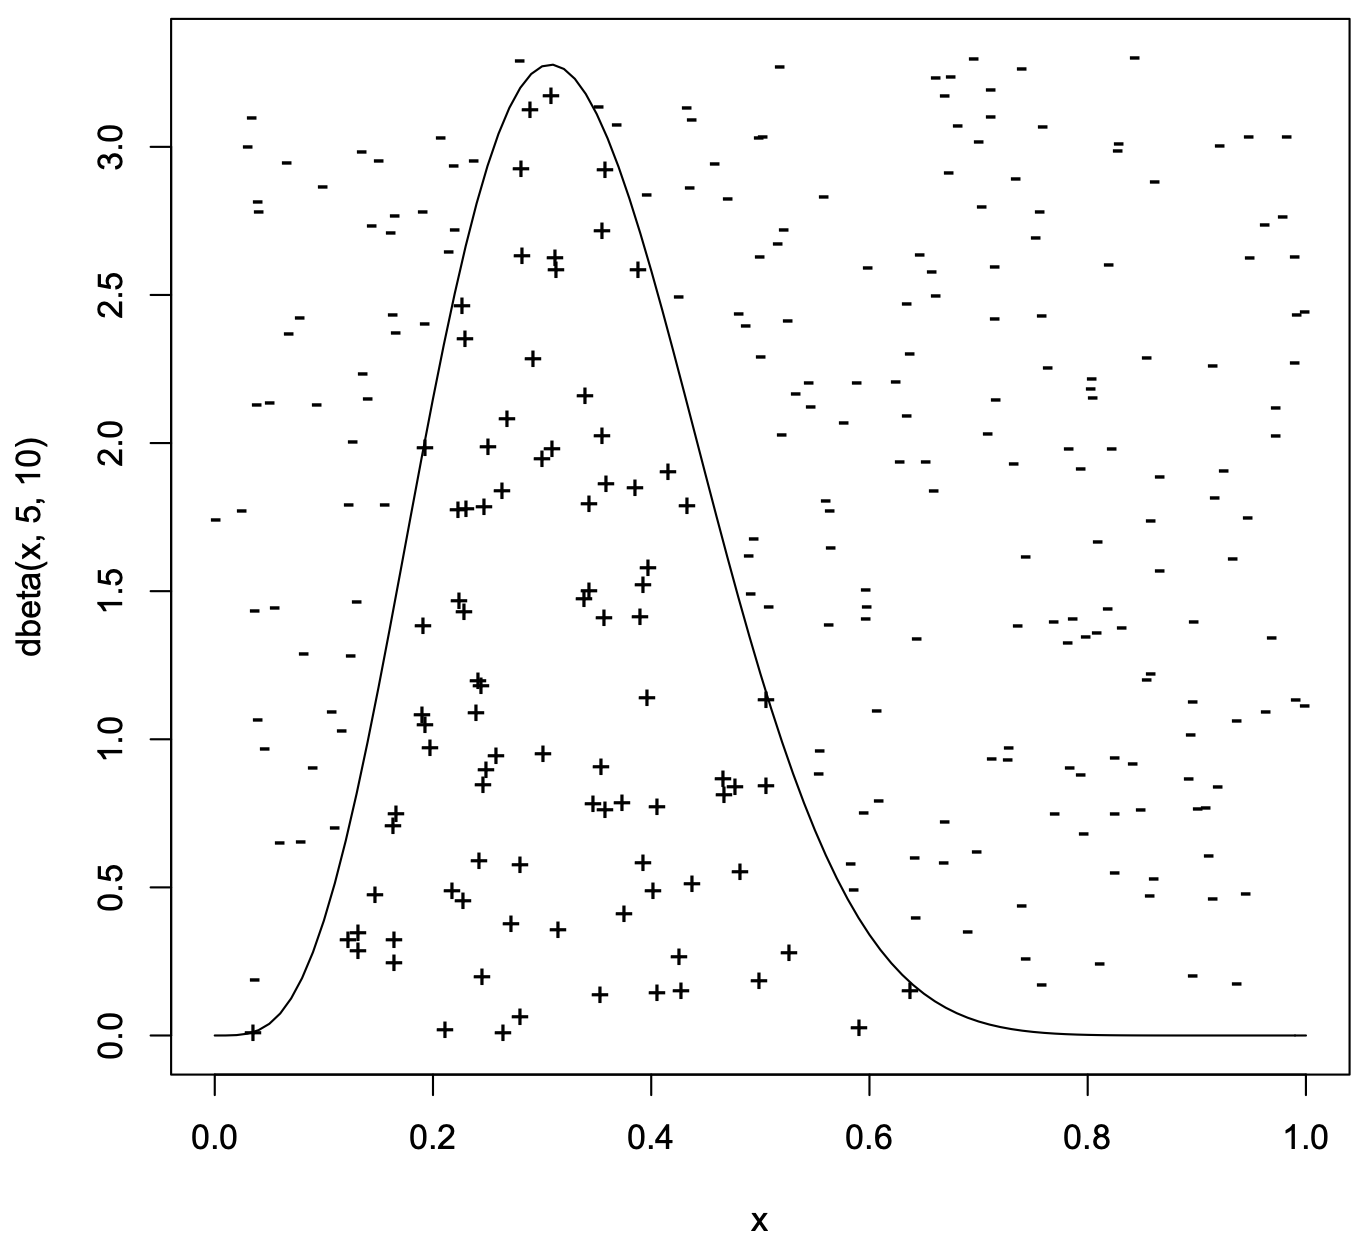

Проиллюстрируем метода отклонения для генерации случайных чисел из распределения $Beta(5,10)$. Предлагаемое распределение является равномерным в диапазоне бета распределения, который составляет $[0, 1]$. Таким образом, точки равномерно отбираются из прямоугольника, который проходит через $[0, 1]$ по горизонтальной оси и $[0, 3.3]$ по вертикальной оси, т.е. $M=3.3$, потому что плотность бета распределения меньше $3.3$ везде. Это не самое низкое возможное значение $M$, но оно близко к нему. Предлагаемые точки, которые находятся ниже функции плотности бета распределения, помечаются знаком «+» и принимаются; те точки, которые находятся выше кривой плотности распределения, помечаются знаком «–» и отклоняются. В рассматриваемом случае ровно 70% предложений отклоняются.

Главный недостаток метода отклонения – скорость. Вероятность принятия сгенерированной точки при любом проходе алгоритма равна $1/M$. Таким образом, для получения $n$ случайных величин требуется в среднем $nM$ циклов алгоритма. Очевидно, мы хотим, чтобы величина $M$ была как можно меньше, а это означает, что мы хотим, чтобы распределение предложений $\rho$ было близко к целевому распределению $f_{Z}$. Конечно, если мы используем метод отклонения, потому что для целевого распределения трудно генерировать точки, а предлагаемое распределение $\rho$ близко к целевому распределению $f_{Z}$, то порождение точек предлагаемого распределения также может быть затруднено.

#### Алгоритм Метрополиса

Один очень важный, но сложный способ обойти ограничения метода отклонения — так называемый алгоритм Метрополиса. И снова у нас есть плотность $f_{Z}$, при помощи которой мы хотим получить выборку. Снова рассматривается предлагаемое распределение и предлагаемые точки принимаются или отклоняются в зависимости от плотности $f_{Z}$. Суть в том, что вместо того, чтобы каждый раз генерировать независимые предлагаемые точки, следующая предлагаемая точка зависит от последней принятой точки — предлагаемое распределение представляет собой условную функцию плотности распределения $\rho\left(r\mid z\right)$. 

Предположим для простоты, что $\rho\left(r\mid z\right)=\rho\left(z\mid r\right)$ (например, у нас может быть гауссово предлагаемое распределение с центром в $z$). Тогда алгоритм Метрополиса состоит в следующем.

1. Начинаем со значения $Z_{0}$ (фиксированного или случайного).

2. Генерируем предлагаемое значение случайной величины $R$ из условного распределения с плотностью $\rho\left(\cdot\mid Z_{t}\right)$. 

3. Генерируем случайную величину $U$ с равномерным распределением и независимую от $R$. 

4. Проверяем, выполняется ли условие $U\leqslant\frac{f_{Z}\left(R\right)}{f_{Z}\left(Z_{t}\right)}$.

    * Если да, то приравниваем $Z_{t+1}=R$ и переходим к шагу 2.

    * Если нет, то приравниваем $Z_{t+1}=Z_{t}$ и переходим к шагу 2.

В простейшем варианте алгоритм не работает до тех пор, пока не получим $t=n$, после чего алгоритм вернет значения $Z_{1},Z_{2},...,Z_{n}$. На практике результат получается лучше, если алгоритм выполняется за $n+n_{0}$ шагов, и первые $n_{0}$ значений $Z_{t}$ отбрасываются — это называется «выжиганием» (“burn-in”).

Обратите внимание, что если $f_{Z}\left(R\right)>f_{Z}\left(Z_{t}\right)$, то предложенное значение $R$ всегда принимается. Алгоритм всегда принимает предложенные значения, которые перемещают его в места, где плотность распределения выше, чем в текущем месте. Если $f_{Z}\left(R\right)<f_{Z}\left(Z_{t}\right)$, то алгоритм принимает предложенное значение с некоторой вероятностью, которая уменьшается по мере снижения плотности распределения в точке $R$. Нетрудно понять, что алгоритм будет проводить больше времени в местах с высоким значением плотности $f_{Z}$.

### Градиентные методы MCMC 

__Методы Монте-Карло с марковскими цепями__ (Markov Chain Monte Carlo, MCMC) — это класс алгоритмов для семплирования (выборки) с некоторым целевым распределение вероятностей. Строится марковская цепь, которая имеет целевое распределение в качестве своего равновесного, тогда можно получить выборку с тем же распределением путем записи состояний цепи. Чем больше шагов будет использовано, тем ближе распределение выборки будет к целевому. 

Обычным выбором для MCMC является динамика Ланжевена (Langevin dynamics, LD), которая моделирует диффузионный процесс (стохастическое дифференциальное уравнение)

$$ d\mathbf{x}_t = \frac{1}{2}  \nabla_{\mathbf{x}_t}\log p_{\theta}\left(\mathbf{x}_t\right)dt + d\mathbf{w}_t,$$
где $\mathbf{w}_t$ - векторный винеровский процесс. При достаточно слабых допущениях распределения $\mathbf{x}_t$ сходятся к целевому распределению $p_{\theta}\left(\mathbf{x}\right)$ независимо от выбранного начального распределения $\mathbf{x}_{0}$. 

Динамика Ланжевена использует тот факт, что градиент логарифмического правдоподобия относительно $\mathbf{x}$ равен (отрицательному) градиенту энергии, и поэтому его легко вычислить:

$$\nabla_{\mathbf{x}}\log p_{\theta}\left(\mathbf{x}\right)=-\nabla_{\mathbf{x}}\mathcal{E}_{\theta}\left(\mathbf{x}\right)-\underbrace{\nabla_{\mathbf{x}}\log Z_{\theta}}_{=0}=-\nabla_{\mathbf{x}}\mathcal{E}_{\theta}\left(\mathbf{x}\right)$$

Например, при использовании MCMC с динамикой Ланжевена для получения выборки из распределения  $p_{\theta}\left(\mathbf{x}\right)$ мы сначала извлекаем начальную выборку $\mathbf{x}^{0}$ из простого априорного распределения, а затем моделируем процесс диффузии Ланжевена с избыточным затуханием (overdamped) для $K$ шагов с размером шага $\epsilon>0$:

$$\mathbf{x}^{k+1}=\mathbf{x}^{k}+\frac{\epsilon^{2}}{2}\,\underbrace{\nabla_{\mathbf{x}}\log p_{\theta}\left(\mathbf{x}^{k}\right)}_{=-\nabla_{\mathbf{x}}\mathcal{E}_{\theta}\left(\mathbf{x}^{k}\right)}+\epsilon\,\mathbf{z}^{k},\,k=0,1,...,K-1,$$

где $\mathbf{z}^{k}\sim\mathcal{N}\left(\mathbf{0},\,\mathbf{I}\right)$ – многомерный гауссовский шум. 

Когда $\epsilon\rightarrow0$ и $K\rightarrow\infty$, переменная $\mathbf{x}^{K}$ гарантированно имеет распределение как у $p_{\theta}\left(\mathbf{x}\right)$ при некоторых условиях регулярности. На практике нам приходится использовать небольшое конечное $\epsilon$, но ошибка дискретизации обычно незначительна.

### Констрастная дивергенция

Выполнение MCMC до сходимости для получения выборки $\mathbf{x}\sim p_{\theta}\left(\mathbf{x}\right)$ может оказаться дорогостоящим в вычислительном отношении. Поэтому нам обычно нужны приближенные методы, чтобы сделать обучение EBM на основе MCMC практичным. Одним из популярных методов для этого является контрастная дивергенция. 

__Контрастная дивергенция__ (contrastive divergence, CD) — это алгоритм обучения, используемый в основном для обучения энергетических моделей и  разработанный лауреатом Нобелевской премии 2024 года Джеффри Хинтоном и его коллегами.

Контрастная дивергенция решает вычислительную проблему, связанную с функцией разбиения (partition function) $Z_{\theta}$ в EBM. Ключевая идея CD заключается в том, что обучение этих моделей возможно без вычисления полной функции разбиения $Z_{\theta}$. Вместо этого CD фокусируется на корректировке параметров модели $\theta$ таким образом, чтобы вероятность наблюдаемых (реальных) данных увеличивалась, а вероятность данных, генерируемых моделью, уменьшалась.

Для этого CD выполняет процедуру выборки Гиббса, начиная с обучающих данных, чтобы получить точки, которые модель считает вероятными. Затем модель использует эти точки для оценки градиента логарифмического правдоподобия обучающих данных относительно параметров модели. Этот градиент используется для обновления параметров в направлении, улучшающем представление данных моделью.

Алгоритм CD называется "контрастной дивергенцией", поскольку он сопоставляет обновления, управляемые данными, и обновления, управляемые моделью. Часть названия "дивергенция" относится к тому факту, что алгоритм минимизирует меру дивергенции между распределением данных и распределением модели.

В контрастной дивергенции инициализируется цепочка MCMC из точки данных $\mathbf{x}$ и MCMC выполняется в течение фиксированного количества шагов. Можно показать, что $T$ шагов контрастной дивергенции минимизируют следующую целевую функцию:

$$CD_{T}=D_{KL}\left(p_{0}\parallel p_{\infty}\right)-D_{KL}\left(p_{T}\parallel p_{\infty}\right),$$

где $p_{T}$ — распределение по $\mathbf{x}$ после $T$ обновлений MCMC, а $p_{0}$ — начальное распределение в наборе данных, $p_{\infty}$ – распределение модели EBM. Обычно мы можем получить хорошие результаты с небольшим значением $T$, иногда даже при $T=1$. 

### Энергетические модели

Ключевая идея энергетической модели (EBM) заключается в том, что мы можем использовать методы аппроксимации, чтобы гарантировать, что нам никогда не придется вычислять трудновычислимый знаменатель. Это отличается, скажем, от подхода в нормализующем потоке, где мы прилагаем все усилия, чтобы гарантировать, что преобразования, которые мы применяем к нашему стандартному гауссовскому распределению, обеспечивают, что выходные данные по-прежнему являются действительным распределением вероятностей.

Мы обходим сложную и неразрешимую проблему знаменателя, используя метод, называемый __контрастной дивергенцией__ (contrastive divergence) для обучения и метод, называемый __динамикой Ланжевена__, для построения выборки. 

### Иллюстративный пример EBM

In [1]:
from silence_tensorflow import silence_tensorflow
silence_tensorflow()

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
tf.__version__

'2.18.0'

In [3]:
import tensorflow.keras as keras

from tensorflow.keras import ( 
    datasets,
    layers,
    models,
    optimizers,
    activations,
    metrics,
    callbacks,
)

import random
import scipy
import sklearn
import sklearn.datasets
import matplotlib.pyplot as plt
import scipy.stats
import seaborn as sns
from sklearn.utils import shuffle as util_shuffle
from functools import partial

In [4]:
def sample_batch(dataset):
    batch = dataset.take(1).get_single_element()
    if isinstance(batch, tuple):
        batch = batch[0]
    return batch.numpy()


def display(
    images, n=10, size=(20, 3), cmap="gray_r", 
    as_type="float32", save_to=None
):
    """
    Displays n random images from each one of the supplied arrays.
    """
    if images.max() > 1.0:
        images = images / 255.0
    elif images.min() < 0.0:
        images = (images + 1.0) / 2.0

    plt.figure(figsize=size)
    for i in range(n):
        _ = plt.subplot(1, n, i + 1)
        plt.imshow(images[i].astype(as_type), cmap=cmap)
        plt.axis("off")

    if save_to:
        plt.savefig(save_to)
        print(f"\nSaved to {save_to}")

    plt.show()


###  Стохастическая градиентная динамика Ланжевена (SGLD)

Стохастическая градиентная динамика Ланжевена (Stochastic Gradient Langevin Dynamics, SGLD) адаптирована для использования стохастических градиентов. Используем формулу 

$$\mathbf{x}^{k+1}=\mathbf{x}^{k}-\frac{\epsilon^{2}}{2}\nabla_{\mathbf{x}}\mathcal{E}_{\theta}\left(\mathbf{x}^{k}\right)+\epsilon\,\mathbf{z}^{k},\,k=0,1,...,K-1,$$
с обрезкой градиентов.

In [5]:
@tf.function
def sgld_sample(E, x_initial, num_steps, step_size, 
                std_dev, clip_thresh=tf.constant(0.1)):
    """
    Do SGLD (stochastic gradient Langevin dynamics) sampling step
    :param E: Energy function
    :param x_initial: initial sample position, of shape 
        (batch_size, ndims)
    :param num_steps: number of sampling steps
    :param step_size: step size used in gradient part
    :param std_dev: standard deviation for isotropic Gaussian 
        used in update
    :param clip_thresh: threshold for gradient clipping; prevents 
        energy gradients from growing too large
    :return: new sample
    """
    x_k = x_initial
    for _ in range(num_steps):
        with tf.GradientTape() as g:
            g.watch(x_k)
            energy = tf.math.reduce_sum(E(x_k))
        # обрезка градиента
        dE_dx = tf.clip_by_norm(g.gradient(energy, x_k), clip_thresh) 
        x_k = x_k - (step_size / 2) * dE_dx + \
            tf.random.normal(x_k.shape, mean=0.0, stddev=std_dev)
    return x_k

I0000 00:00:1762947555.681298 15759086 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1762947555.681319 15759086 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


## Использование EBM для моделирования простых распределений

Модели EBM используют функцию энергии для моделирования распределения данных. Любую энергетическую функцию можно превратить в распределение с помощью распределения Больцмана; однако для этого требуется оценить статистическую сумму распределения Больцмана, что невозможно в более высоких измерениях. Альтернативой оценке статистической суммы является использование методов MCMC для получения выборок, поскольку существуют подходы (например, используемый здесь SGLD), которые не требуют оценки статистической суммы; это позволяет генерировать синтетические данные с учетом энергетической функции. Энергетическая функция связывает низкие энергии с правильными значениями, а более высокие энергии — с неправильными значениями. Идея EBM состоит в том, чтобы изучить эту энергетическую функцию с использованием максимального правдоподобия, используя нейронную сеть в качестве энергетической функции и используя SGLD для аппроксимации распределения Больцмана. 

Для инициализации модуля оптимизации используется буфер воспроизведения прошлых значений (replay buffer). 

Класс, реализующий подгонку EBM, приведен ниже:

In [6]:
class EBM1:
    def __init__(self, energy_fn, replay_buffer_size=10000):
        self.energy = energy_fn
        self.replay_buffer = []
        self.replay_buffer_ptr = 0
        self.replay_buffer_max = replay_buffer_size
    
    def sample_sgld(self, x_init, batch_size, 
                    num_steps_markov=tf.constant(25), 
                    step_size=tf.constant(10.0), 
                    std_dev=tf.constant(0.005), 
                    clip_thresh=tf.constant(0.01)):
        return sgld_sample(self.energy, x_init, num_steps_markov, 
                           step_size, std_dev, clip_thresh=clip_thresh)


    def sample_replay_buffer(self, batch_size, uniform_bounds_lower, 
                             uniform_bounds_upper,
                             num_steps_markov=tf.constant(25), 
                             step_size=tf.constant(10.0),
                             std_dev=tf.constant(0.005), 
                             clip_thresh=tf.constant(0.01)):
        # Choose initial points, either from replay buffer or 
        # from uniform distribution with bounds given by the user
        initial_points = []
        for _ in range(batch_size):
            prob_replay = np.random.uniform()
            if len(self.replay_buffer)<batch_size or prob_replay>=0.95:
                x_k = np.random.uniform(uniform_bounds_lower, 
                                        uniform_bounds_upper, (1, 2))
            else:
                x_k_index = np.random.choice(len(self.replay_buffer))
                x_k = tf.reshape(self.replay_buffer[x_k_index], 
                    (1, self.replay_buffer[x_k_index].shape[-1]))
            x_k = tf.convert_to_tensor(x_k, dtype=tf.float32)
            initial_points.append(x_k)
        initial_points = tf.concat(initial_points, 0)

        return sgld_sample(self.energy, initial_points, 
                           num_steps_markov, step_size,
                           std_dev, clip_thresh=clip_thresh)

    def _insert_into_replay_buffer(self, data, batch_size):
        for j in range(batch_size):
            if len(self.replay_buffer) <= self.replay_buffer_max:
                self.replay_buffer.append(tf.reshape(data[j], 
                                          (1, data[j].shape[-1])))
            else:
                self.replay_buffer[self.replay_buffer_ptr] = \
                    tf.reshape(data[j], (1, data[j].shape[-1]))
            self.replay_buffer_ptr += 1
            if self.replay_buffer_ptr > self.replay_buffer_max - 1:
                self.replay_buffer_ptr = 0

    def fit(self, data, batch_size, num_epochs, optimizer, 
            uniform_bounds_lower, uniform_bounds_upper,
            alpha=tf.constant(0.1), num_steps_markov=tf.constant(25), 
            step_size=tf.constant(10.0), std_dev=tf.constant(0.005), 
            clip_thresh=tf.constant(0.01), callbacks_energy=[]):
        # Get number of training examples
        n_train = data.shape[0]
        inner_loop_iterations = n_train // batch_size

        # Create dataset sampler
        dataset = tf.data.Dataset.from_tensor_slices(data)
        dataset = dataset.shuffle(buffer_size=n_train)
        dataset = dataset.batch(batch_size, drop_remainder=True)
        dataset = dataset.repeat()
        dataset_iterator = iter(dataset)

        for epoch in range(num_epochs):
            num_samples_processed = 0

            used_std_dev = std_dev
            if callable(std_dev):
                used_std_dev = std_dev(epoch)

            for i in range(inner_loop_iterations):
                avg_abs_diff_energies_data_sample = 0.0
                # Sample from data distribution
                sample_data_dist = next(dataset_iterator)

                # Sample from energy function
                sample_energy_dist = self.sample_replay_buffer(
                    batch_size, 
                    uniform_bounds_lower, 
                    uniform_bounds_upper, 
                    num_steps_markov=num_steps_markov, 
                    step_size=step_size,
                    std_dev=used_std_dev, 
                    clip_thresh=clip_thresh
                )
                self._insert_into_replay_buffer(
                    sample_energy_dist, batch_size
                )

                # Compute parameter gradients
                with tf.GradientTape() as g:
                    energies_data = self.energy(
                        sample_data_dist, training=True
                    )
                    energies_samples = self.energy(
                        sample_energy_dist, training=True
                    )
                    energy_data = tf.math.reduce_mean(energies_data)
                    energy_samples = tf.math.reduce_mean(
                        energies_samples
                    )
                    energies_l2 = \
                        tf.math.reduce_mean(tf.square(energies_data)) + \
                        tf.math.reduce_mean(tf.square(energies_samples))
                    energy = energy_data - energy_samples + \
                        alpha * energies_l2
                gradient = g.gradient(energy, 
                                      self.energy.trainable_variables)

                # Apply gradients
                optimizer.apply_gradients(zip(gradient, 
                    self.energy.trainable_variables))

                # Report epoch progress, compute metrics
                avg_abs_diff_energies_data_sample += \
                    (1 / inner_loop_iterations) * \
                    (tf.abs(energy_data - energy_samples)).numpy()

                num_samples_processed += batch_size
                progress = num_samples_processed / n_train

                print("\rEpoch {:2d}".format(epoch),
                      "progress: {:6.2f}%".format(
                    progress * 100.0), end='  ')
                # Print progress metric
                print("CD: {:12.10f}".format(
                    avg_abs_diff_energies_data_sample), end='  ')

            for callbacks_name, callback_fn in callbacks_energy:
                print(callbacks_name, 
                      ": {:12.10f}".format(callback_fn(self.energy)))

#### Визуализация

Для визуализации функции плотности и энергии используются контурные графики.

In [7]:
def create_contour_plot(f, transpose=False):
    num_points = 250
    x_surface = np.linspace(-3, 3, num_points)
    y_surface = np.linspace(-3, 3, num_points)
    X, Y = np.meshgrid(x_surface, y_surface)
    combined = np.vstack((X.flatten(), Y.flatten())).T
    if transpose:
        Z = f(combined.T)
    else:
        Z = f(combined)
    plt.contourf(X, Y, Z.reshape(X.shape), levels=20)
    plt.colorbar()
    plt.show()
    return Z

In [8]:
def create_contour_plot_tensorflow(E):
    num_points = 250
    x_surface = np.linspace(-3, 3, num_points)
    y_surface = np.linspace(-3, 3, num_points)
    X, Y = np.meshgrid(x_surface, y_surface)
    combined = np.vstack((X.flatten(), Y.flatten())).T
    combined = tf.convert_to_tensor(combined, dtype=tf.float32)
    Z = E(combined).numpy()
    plt.contourf(X, Y, Z.reshape(X.shape), levels=20)
    plt.colorbar()
    plt.show()

#### Оценка

Количественный способ оценить сходство двух плотностей распределения  можно реализовать с помощью метрики расстояния для плотностей. Для этого используется расстояние Дженсена-Шеннона. Оно тесно связано с дивергенцией Кульбака-Лейбера, но является истинной метрикой расстояния и ограничено интервалом $[-1, 1]$.

In [9]:
def jensen_shannon_distance_kde(energy, pdf_kde):
    num_points = 250
    x = np.linspace(-3, 3, num_points)
    y = np.linspace(-3, 3, num_points)
    X, Y = np.meshgrid(x, y)
    combo = np.vstack((X.flatten(), Y.flatten())).T
    combo = tf.convert_to_tensor(combo, dtype=tf.float32)
    Z = np.exp(-energy(combo).numpy().reshape(num_points, num_points))
    partition = np.sum(Z)
    pdf = Z / partition
    return scipy.spatial.distance.jensenshannon(pdf.flatten(), 
                                                pdf_kde.flatten())

#### Плотность распределения данных

Чтобы оценить качество EBM, было бы очень полезно иметь плотность распределения для этого набора данных. Однако плотность распределения  здесь, к сожалению, недоступна. Поэтому используется ядерная оценка плотности (KDE), чтобы  приближенно получить плотность распределения.

In [10]:
def make_pdf_data(data, bw_method=0.15):
    kernel = scipy.stats.gaussian_kde(data.T, bw_method=bw_method)
    pdf_kde = create_contour_plot(kernel, transpose=True)
    pdf_kde = pdf_kde / pdf_kde.sum()
    return pdf_kde

#### Плотность  функции энергии

Также оценивается функция распределения и создается плотность распределения для визуализации, используя распределение Больцмана.

In [11]:
def make_pdf_energy(E):
    num_points = 250
    x = np.linspace(-3, 3, num_points)
    y = np.linspace(-3, 3, num_points)
    X, Y = np.meshgrid(x, y)
    combined = np.vstack((X.flatten(), Y.flatten())).T
    combined = tf.convert_to_tensor(combined, dtype=tf.float32)
    Z = np.exp(-E(combined).numpy().reshape(num_points, num_points))
    partition = np.sum(Z)
    pdf = Z / partition
    plt.contourf(X, Y, pdf.reshape(X.shape), levels=1000)
    plt.colorbar()
    return pdf

#### Набор данных swiss roll

Cмоделируем набор данных __swiss roll__:

In [12]:
# Generate swiss roll data
def generate_swiss_roll(batch_size):
    data = sklearn.datasets.make_swiss_roll(n_samples=batch_size, 
                                            noise=1.0)[0]
    data = data.astype("float32")[:, [0, 2]]
    data /= 5
    return data

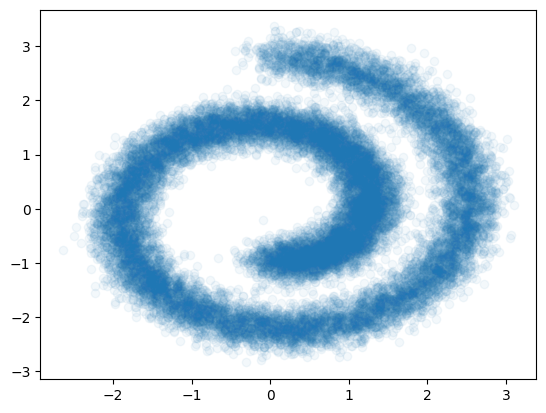

In [13]:
swiss_roll_train = generate_swiss_roll(20000)
plt.scatter(swiss_roll_train[:,0], swiss_roll_train[:,1], alpha=0.05);

Визуализация оценки плотности распределения для этого набора выглядит так:

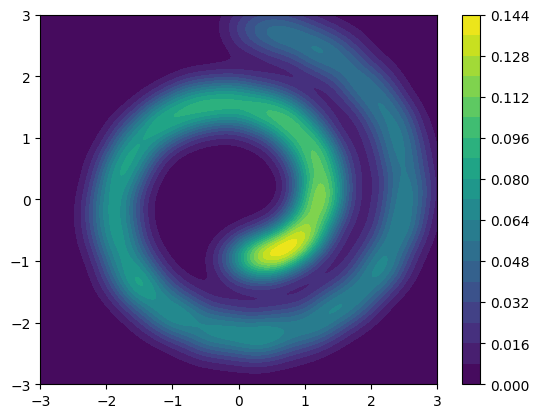

In [14]:
pdf_kde = make_pdf_data(swiss_roll_train)

Будем использовать функцию энергии следующего вида:

In [15]:
input_ = keras.layers.Input(shape=swiss_roll_train.shape[1:])
hidden_1 = keras.layers.Dense(1000, activation="relu")(input_)
hidden_2 = keras.layers.Dense(1000, activation="relu")(hidden_1)
output = keras.layers.Dense(1)(hidden_2)
swiss_roll_model = keras.Model(inputs=[input_], outputs=[output])

In [16]:
swiss_roll_train.shape[1:]

(2,)

In [17]:
swiss_roll_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1000)           │         3,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,001 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,005,001 (3.83 MB)

 Trainable params: 1,005,001 (3.83 MB)

 Non-trainable params: 0 (0.00 B)

#### Обучение сети

В качестве оптимизатора выберем Адам со скоростью обучения 0,001.

In [18]:
optimizer = keras.optimizers.Adam(1e-3)
ebm = EBM1(swiss_roll_model)

In [19]:
ebm.fit(swiss_roll_train, 128, 15, optimizer, [-4, -4], [4, 4], 
        num_steps_markov=tf.constant(10), std_dev=0.1, step_size=0.1, 
        callbacks_energy=[("JSD", partial(jensen_shannon_distance_kde, 
                                          pdf_kde=pdf_kde))],
        alpha=0.1, clip_thresh=tf.constant(1.0))

Epoch  0 progress:  99.84%  CD: 0.0243642479  JSD : 0.2850577122
Epoch  1 progress:  99.84%  CD: 0.0267975386  JSD : 0.2749371738
Epoch  2 progress:  99.84%  CD: 0.0302911289  JSD : 0.2964631587
Epoch  3 progress:  99.84%  CD: 0.0372772776  JSD : 0.3000616091
Epoch  4 progress:  99.84%  CD: 0.0334536545  JSD : 0.2874645430
Epoch  5 progress:  99.84%  CD: 0.0407810211  JSD : 0.2983971429
Epoch  6 progress:  99.84%  CD: 0.0402466916  JSD : 0.2600091281
Epoch  7 progress:  99.84%  CD: 0.0387931615  JSD : 0.2670681139
Epoch  8 progress:  99.84%  CD: 0.0451024622  JSD : 0.2288861610
Epoch  9 progress:  99.84%  CD: 0.0412511900  JSD : 0.2574345640
Epoch 10 progress:  99.84%  CD: 0.0416217111  JSD : 0.2517207668
Epoch 11 progress:  99.84%  CD: 0.0421813205  JSD : 0.2589718546
Epoch 12 progress:  99.84%  CD: 0.0411184132  JSD : 0.2601193129
Epoch 13 progress:  99.84%  CD: 0.0418690592  JSD : 0.2576201242
Epoch 14 progress:  99.84%  CD: 0.0475810058  JSD : 0.2861117221


#### Визуализация  функции энергии

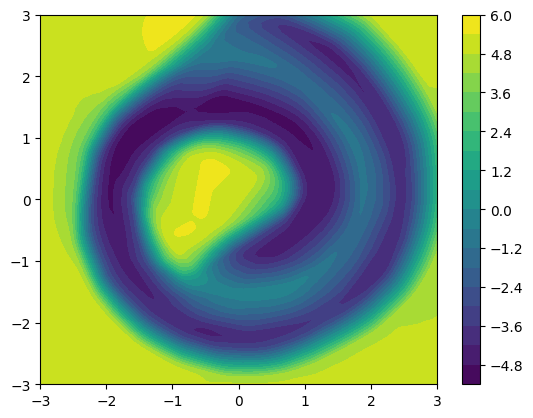

In [20]:
create_contour_plot_tensorflow(swiss_roll_model)

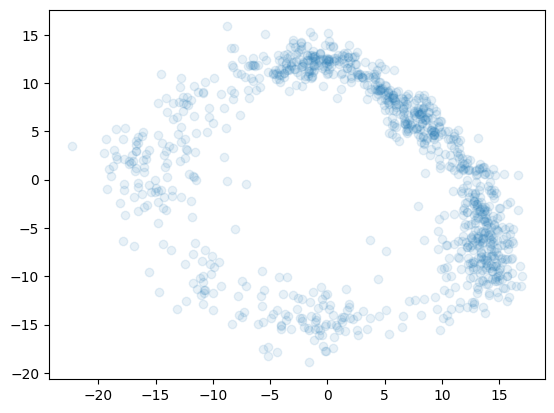

In [21]:
# Sample and plot some points
batch_size = 1000
x_init = tf.random.uniform((batch_size, 2), minval=-3, maxval=3)
sample = sgld_sample(swiss_roll_model, x_init, tf.constant(50), 
                     150, 0.2, clip_thresh=tf.constant(0.1))
plt.scatter(sample[:, 0], sample[:, 1], alpha=0.1);

#### Визуализация плотности распределения, определенной функцией энергии

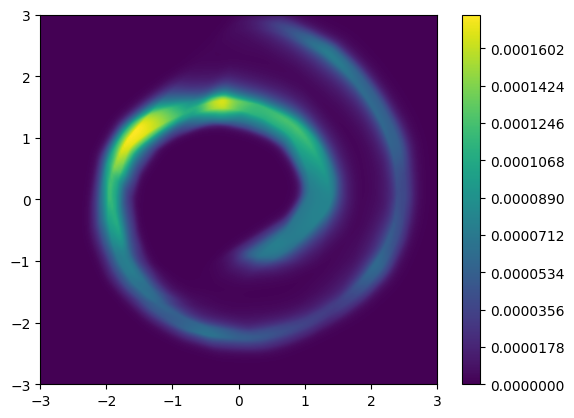

In [22]:
pdf = make_pdf_energy(swiss_roll_model)

Расстояние Дженсена-Шеннона между распределениями равно:

In [23]:
print(scipy.spatial.distance.jensenshannon(
    pdf.flatten(), pdf_kde.flatten()
))

0.286111722131844


#### Набор данных Gaussians

In [24]:
batch_size = 5000
rng = np.random.RandomState()
scale = 4.
centers = [(1, 0), (-1, 0), (0, 1), (0, -1), (1. / np.sqrt(2), 1. / np.sqrt(2)),
           (1. / np.sqrt(2), -1. / np.sqrt(2)), (-1. / np.sqrt(2),
                                                 1. / np.sqrt(2)), (-1. / np.sqrt(2), -1. / np.sqrt(2))]
centers = [(scale * x, scale * y) for x, y in centers]

dataset = []
for i in range(batch_size):
    point = rng.randn(2) * 0.5
    idx = rng.randint(8)
    center = centers[idx]
    point[0] += center[0]
    point[1] += center[1]
    dataset.append(point)
dataset = np.array(dataset, dtype="float32")
dataset /= 1.414
gaussians_train = dataset

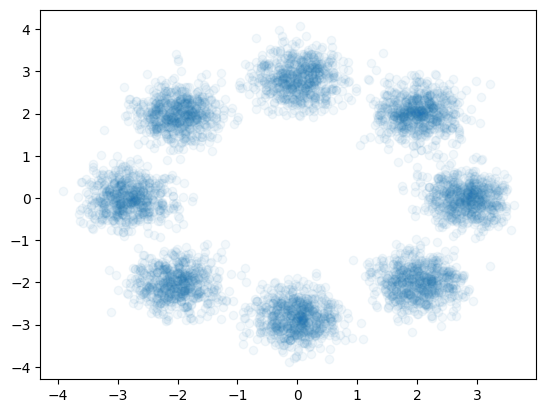

In [25]:
plt.scatter(gaussians_train[:, 0], gaussians_train[:, 1], alpha=0.05);

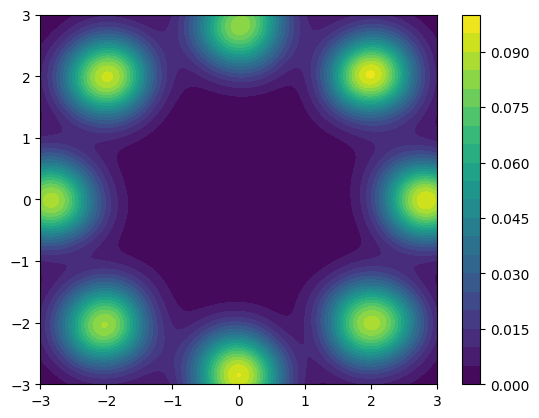

In [26]:
pdf_kde = make_pdf_data(gaussians_train)

In [27]:
input_ = keras.layers.Input(shape=gaussians_train.shape[1:])
hidden_1 = keras.layers.Dense(1000, activation="relu")(input_)
hidden_2 = keras.layers.Dense(1000, activation="relu")(hidden_1)
output = keras.layers.Dense(1)(hidden_2)
gaussians_model = keras.Model(inputs=[input_], outputs=[output])

In [28]:
optimizer = keras.optimizers.Adam(1e-3)
ebm = EBM1(gaussians_model)

In [29]:
ebm.fit(gaussians_train, 128, 30, optimizer, [-4.5, -4.5], [4.5, 4.5], num_steps_markov=tf.constant(10),
        std_dev=0.1, step_size=0.1, callbacks_energy=[("JSD", partial(jensen_shannon_distance_kde, pdf_kde=pdf_kde))],
        alpha=0.1, clip_thresh=tf.constant(1.0))

Epoch  0 progress:  99.84%  CD: 0.0209458247  JSD : 0.4680716799
Epoch  1 progress:  99.84%  CD: 0.0541062132  JSD : 0.4134522144
Epoch  2 progress:  99.84%  CD: 0.0748505443  JSD : 0.2663648347
Epoch  3 progress:  99.84%  CD: 0.0929370299  JSD : 0.2722067882
Epoch  4 progress:  99.84%  CD: 0.1020921245  JSD : 0.2694698282
Epoch  5 progress:  99.84%  CD: 0.1152915955  JSD : 0.2573476512
Epoch  6 progress:  99.84%  CD: 0.1189014241  JSD : 0.2705872314
Epoch  7 progress:  99.84%  CD: 0.1069706157  JSD : 0.2784560542
Epoch  8 progress:  99.84%  CD: 0.1205938905  JSD : 0.2688446603
Epoch  9 progress:  99.84%  CD: 0.1314472854  JSD : 0.2933409308
Epoch 10 progress:  99.84%  CD: 0.1278290302  JSD : 0.2748565346
Epoch 11 progress:  99.84%  CD: 0.1128111407  JSD : 0.3053060676
Epoch 12 progress:  99.84%  CD: 0.1379951835  JSD : 0.2942349464
Epoch 13 progress:  99.84%  CD: 0.1184019968  JSD : 0.2997119701
Epoch 14 progress:  99.84%  CD: 0.1289057583  JSD : 0.3448469104
Epoch 15 progress:  99.84

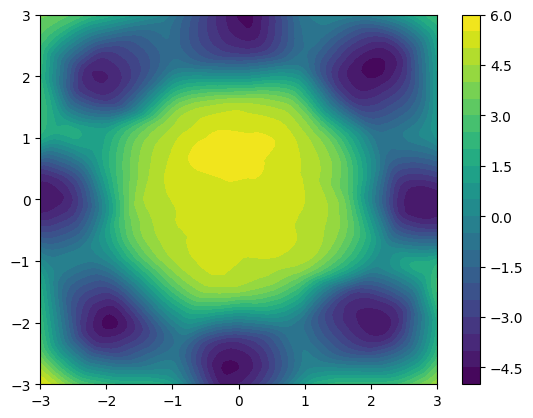

In [30]:
create_contour_plot_tensorflow(gaussians_model)

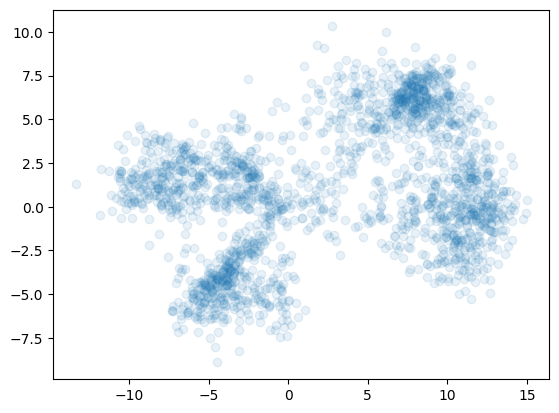

In [31]:
# Sample and plot some points
batch_size = 2000
x_init = tf.random.uniform((batch_size, 2), minval=-3, maxval=3)
sample = sgld_sample(gaussians_model, x_init, tf.constant(30), 20, 0.20, clip_thresh=tf.constant(1.0))
plt.scatter(sample[:, 0], sample[:, 1], alpha=0.1);

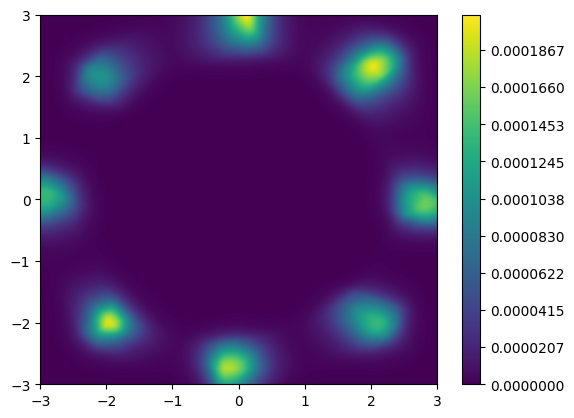

In [32]:
pdf = make_pdf_energy(gaussians_model)

### Набор данных "вертушка" (Pinwheel)

In [33]:
batch_size = 10000
rng = np.random.RandomState()
radial_std = 0.3
tangential_std = 0.1
num_classes = 5
num_per_class = batch_size // 5
rate = 0.25
rads = np.linspace(0, 2 * np.pi, num_classes, endpoint=False)

features = rng.randn(num_classes*num_per_class, 2) \
    * np.array([radial_std, tangential_std])
features[:, 0] += 1.
labels = np.repeat(np.arange(num_classes), num_per_class)

angles = rads[labels] + rate * np.exp(features[:, 0])
rotations = np.stack([np.cos(angles), -np.sin(angles), np.sin(angles), np.cos(angles)])
rotations = np.reshape(rotations.T, (-1, 2, 2))

pinwheel_train = rng.permutation(np.einsum("ti,tij->tj", features, rotations))

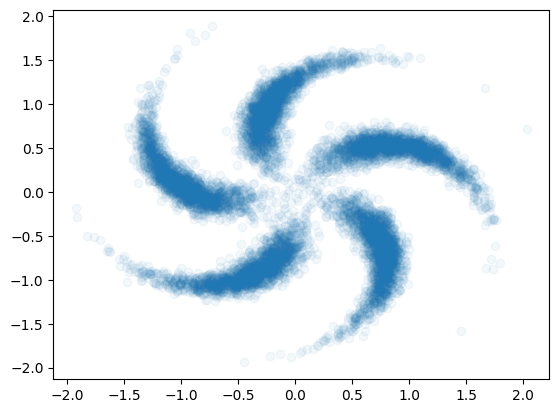

In [34]:
plt.scatter(pinwheel_train[:, 0], pinwheel_train[:, 1], alpha=0.05);

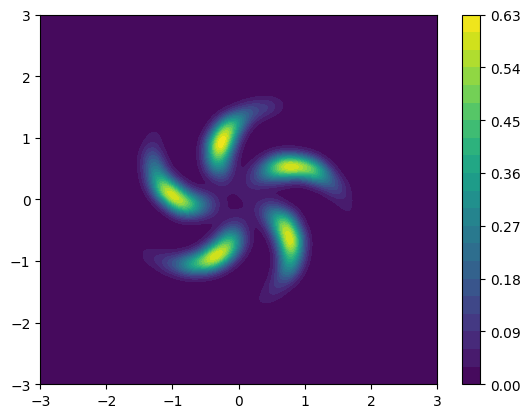

In [35]:
pdf_kde = make_pdf_data(pinwheel_train)

In [36]:
input_ = keras.layers.Input(shape=pinwheel_train.shape[1:])
hidden_1 = keras.layers.Dense(1000, activation="relu")(input_)
hidden_2 = keras.layers.Dense(1000, activation="relu")(hidden_1)
output = keras.layers.Dense(1)(hidden_2)
pinwheel_model = keras.Model(inputs=[input_], outputs=[output])

In [37]:
optimizer = keras.optimizers.Adam(1e-3)
ebm = EBM1(pinwheel_model)

In [38]:
ebm.fit(pinwheel_train, 128, 25, optimizer, [-3, -3], [3, 3], num_steps_markov=tf.constant(10),
        std_dev=0.05, step_size=0.05, callbacks_energy=[("JSD", partial(jensen_shannon_distance_kde, pdf_kde=pdf_kde))],
        alpha=0.1, clip_thresh=tf.constant(1.0))

Epoch  0 progress:  99.84%  CD: 0.0681849867  JSD : 0.3969731429
Epoch  1 progress:  99.84%  CD: 0.0720091388  JSD : 0.3741110800
Epoch  2 progress:  99.84%  CD: 0.0738198459  JSD : 0.3711972572
Epoch  3 progress:  99.84%  CD: 0.0732983723  JSD : 0.3580406392
Epoch  4 progress:  99.84%  CD: 0.0702152774  JSD : 0.3425999208
Epoch  5 progress:  99.84%  CD: 0.0702891201  JSD : 0.3269173346
Epoch  6 progress:  99.84%  CD: 0.0789746419  JSD : 0.3429993297
Epoch  7 progress:  99.84%  CD: 0.0789195448  JSD : 0.2888006189
Epoch  8 progress:  99.84%  CD: 0.0723198131  JSD : 0.2823358612
Epoch  9 progress:  99.84%  CD: 0.0779823139  JSD : 0.2837768094
Epoch 10 progress:  99.84%  CD: 0.0726032108  JSD : 0.2666670723
Epoch 11 progress:  99.84%  CD: 0.0790242106  JSD : 0.2811865071
Epoch 12 progress:  99.84%  CD: 0.0780980065  JSD : 0.2926729436
Epoch 13 progress:  99.84%  CD: 0.0783505067  JSD : 0.2791310218
Epoch 14 progress:  99.84%  CD: 0.0829538330  JSD : 0.2800294041
Epoch 15 progress:  99.84

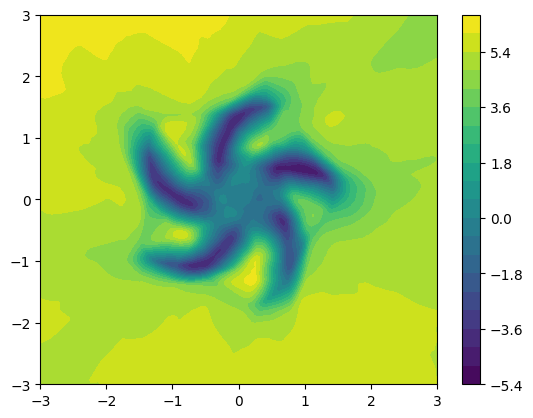

In [39]:
create_contour_plot_tensorflow(pinwheel_model)

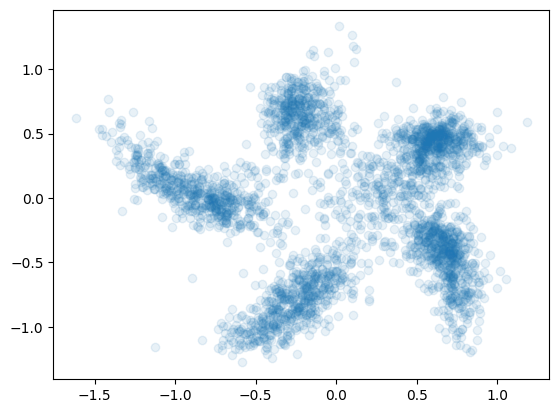

In [40]:
# Sample and plot some points
batch_size = 3000
x_init = tf.random.uniform((batch_size, 2), minval=-1, maxval=1)
sample = sgld_sample(pinwheel_model, x_init, tf.constant(30), 3.1, 0.065, clip_thresh=tf.constant(1.0))
plt.scatter(sample[:, 0], sample[:, 1], alpha=0.1);

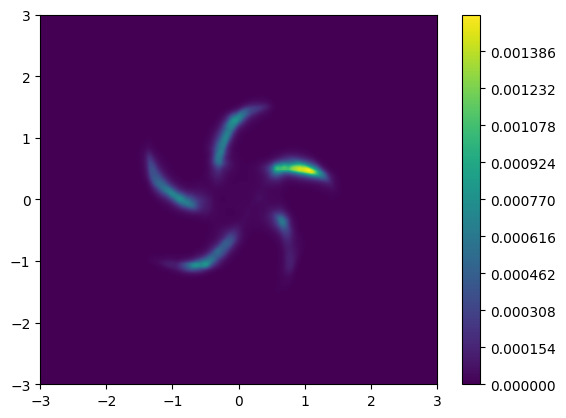

In [41]:
pdf = make_pdf_energy(pinwheel_model)

#### Набор данных "шахматная доска" (Checkerboard)

In [42]:
batch_size = 10000
x1 = np.random.rand(batch_size) * 4 - 2
x2_ = np.random.rand(batch_size) - np.random.randint(0, 2, batch_size) * 2
x2 = x2_ + (np.floor(x1) % 2)
checkerboard_train = np.concatenate([x1[:, None], x2[:, None]], 1) * 2

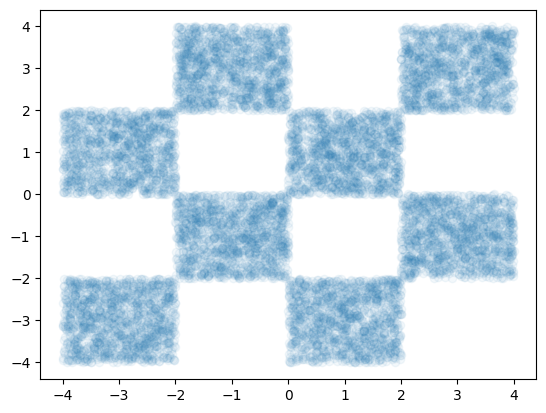

In [43]:
plt.scatter(checkerboard_train[:, 0], checkerboard_train[:, 1], alpha=0.05);

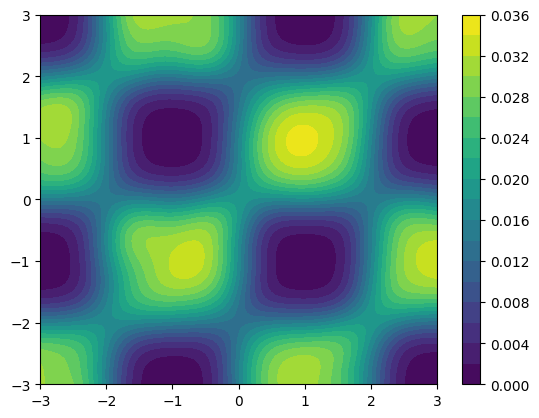

In [44]:
pdf_kde = make_pdf_data(checkerboard_train)

In [45]:
input_ = keras.layers.Input(shape=checkerboard_train.shape[1:])
hidden_1 = keras.layers.Dense(1000, activation="relu")(input_)
hidden_2 = keras.layers.Dense(1000, activation="relu")(hidden_1)
output = keras.layers.Dense(1)(hidden_2)
checkerboard_model = keras.Model(inputs=[input_], outputs=[output])

In [46]:
ebm = EBM1(checkerboard_model)

In [47]:
optimizer = keras.optimizers.Adam(1e-3)
ebm.fit(checkerboard_train, 128, 30, optimizer, [-4.5, -4.5], [4.5, 4.5], num_steps_markov=tf.constant(25),
        std_dev=0.1, step_size=0.1, callbacks_energy=[("JSD", partial(jensen_shannon_distance_kde, pdf_kde=pdf_kde))],
        alpha=0.5, clip_thresh=tf.constant(1.0))

Epoch  0 progress:  99.84%  CD: 0.0021639699  JSD : 0.2313566969
Epoch  1 progress:  99.84%  CD: 0.0031429459  JSD : 0.2249968015
Epoch  2 progress:  99.84%  CD: 0.0035072428  JSD : 0.2137483155
Epoch  3 progress:  99.84%  CD: 0.0044150129  JSD : 0.2008024894
Epoch  4 progress:  99.84%  CD: 0.0034891099  JSD : 0.1851980456
Epoch  5 progress:  99.84%  CD: 0.0057206047  JSD : 0.1742515971
Epoch  6 progress:  99.84%  CD: 0.0059682033  JSD : 0.1626511473
Epoch  7 progress:  99.84%  CD: 0.0072219893  JSD : 0.1548373335
Epoch  8 progress:  99.84%  CD: 0.0052444804  JSD : 0.1664530376
Epoch  9 progress:  99.84%  CD: 0.0082440712  JSD : 0.1618856622
Epoch 10 progress:  99.84%  CD: 0.0078208093  JSD : 0.1394185304
Epoch 11 progress:  99.84%  CD: 0.0071615549  JSD : 0.1451734013
Epoch 12 progress:  99.84%  CD: 0.0090964464  JSD : 0.1296898402
Epoch 13 progress:  99.84%  CD: 0.0068731890  JSD : 0.1331863497
Epoch 14 progress:  99.84%  CD: 0.0085886009  JSD : 0.1264485938
Epoch 15 progress:  99.84

In [48]:
batch_size = 2000
x_init = tf.random.uniform((batch_size, 2), minval=-4, maxval=4)
sample = sgld_sample(
    checkerboard_model, x_init, tf.constant(50), 25, 0.095, 
    clip_thresh=tf.constant(0.1)
)

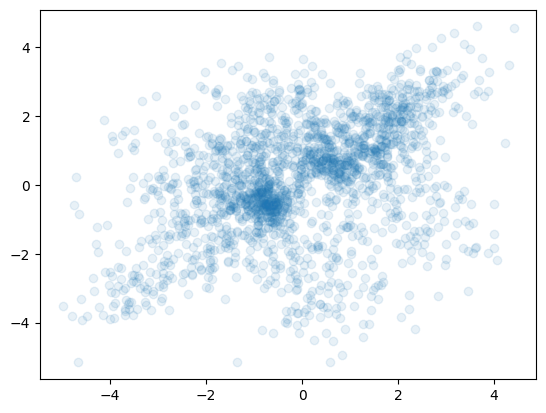

In [49]:
plt.scatter(sample[:, 0], sample[:, 1], alpha=0.1);

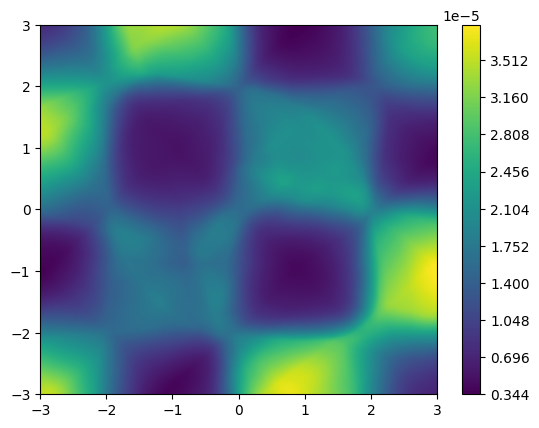

In [50]:
pdf = make_pdf_energy(checkerboard_model)

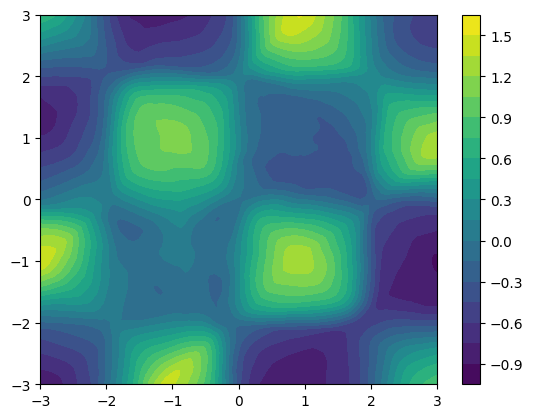

In [51]:
create_contour_plot_tensorflow(checkerboard_model)